In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Step 1: Load the dataset
url = './diabetes.csv'  # Change to actual file path if locally stored
df = pd.read_csv(url)

In [5]:
# Step 2: Data Preprocessing
# Check for any null values
print("Null values:\n", df.isnull().sum())

Null values:
 Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64


In [6]:
# Define feature set (X) and target variable (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [7]:
# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [8]:
# Step 4: Data Normalization (KNN benefits from scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
# Step 5: Implement K-Nearest Neighbors
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
# Step 6: Make Predictions
y_pred = knn.predict(X_test)


In [11]:
# Step 7: Compute Performance Metrics
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)


In [12]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Error Rate
error_rate = 1 - accuracy

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)


In [13]:
# Print results
print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Confusion Matrix:
 [[119  32]
 [ 37  43]]
Accuracy: 0.7013
Error Rate: 0.2987
Precision: 0.5733
Recall: 0.5375


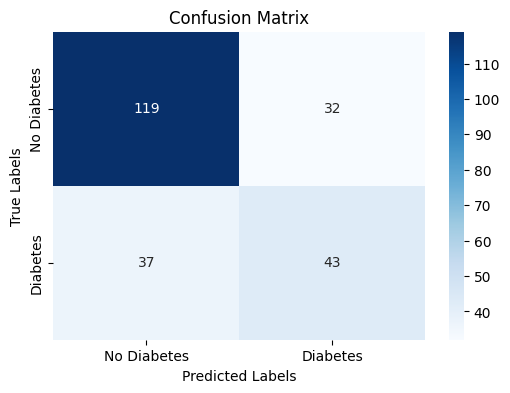

In [14]:
# Step 8: Visualizations
# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

C:\Users\surya\AppData\Local\Temp\ipykernel_9940\1048213116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis")


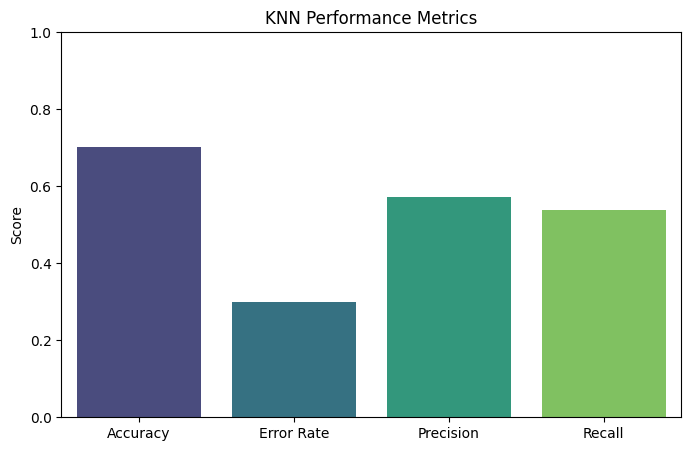

In [15]:
# Performance Metrics Bar Plot
metrics = ["Accuracy", "Error Rate", "Precision", "Recall"]
values = [accuracy, error_rate, precision, recall]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette="viridis")
plt.ylim(0, 1)
plt.title("KNN Performance Metrics")
plt.ylabel("Score")
plt.show()